In [89]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size" : 20,
    "xtick.labelsize" : 20, 
    "ytick.labelsize" : 20,
    #"font.sans-serif": "Helvetica",
})

from scipy.optimize import curve_fit

In [90]:
L,eta = np.loadtxt("Source-Fig01a.csv", delimiter = ',', skiprows = 1).T
I, Pinc = np.loadtxt("Source-Fig01b.csv", delimiter = ',', skiprows = 1).T
print(L)

[ 349.57  360.05  369.88  379.39  389.56  399.41  409.92  419.77  429.96
  439.81  450.32  459.52  469.38  479.89  490.07  500.26  510.44  520.62
  529.5   539.68  550.19  559.72  570.23  580.74  590.6   600.78  609.98
  619.84  630.02  640.53  650.39  660.57  670.43  680.94  690.14  700.32
  710.5   720.68  730.86  740.72  750.9   761.08  770.28  780.46  790.97
  801.15  811.    821.17  831.35  841.53  850.72  861.08  871.22  881.55
  891.27  901.61  911.53  921.87  930.96  941.09  951.42  961.35  971.67
  981.58  991.89 1001.98 1011.01 1021.06 1031.07 1041.26 1051.44 1061.2
 1070.98 1079.98 1090.02 1100.29]


# Détermination de l'ordre global

In [137]:
P = lambda x : 3.18 + 20.42 * x + 0.21 * x**2 + 8.9*10**(-3) * x**3 + 2.34 * 10**(-4) * x**4 

fit = np.poly1d(np.polyfit(I, Pinc, deg = 4))

fit2 = lambda L, c0, c1, K, L0, L1 : ((c0 + c1)* (L-L1)) * np.exp(K*(L-L0)) / (1+np.exp(K*(L-L0))) 
#(c0 + c1 * L + c2 * L**0.25) / (1+np.exp(K*(L-L0)))


cm1, c0, c1, K, L0, L1 = 1.0, 1.0, 1.0, 0.05, 1050, 400

p, pcov = curve_fit(fit2, L, eta, p0 = (c0, c1, K, L0, L1))

print(p)

[ 9.77392889e+03 -9.77397833e+03  6.02504447e-03  1.35425148e+03
  1.10714877e+03]


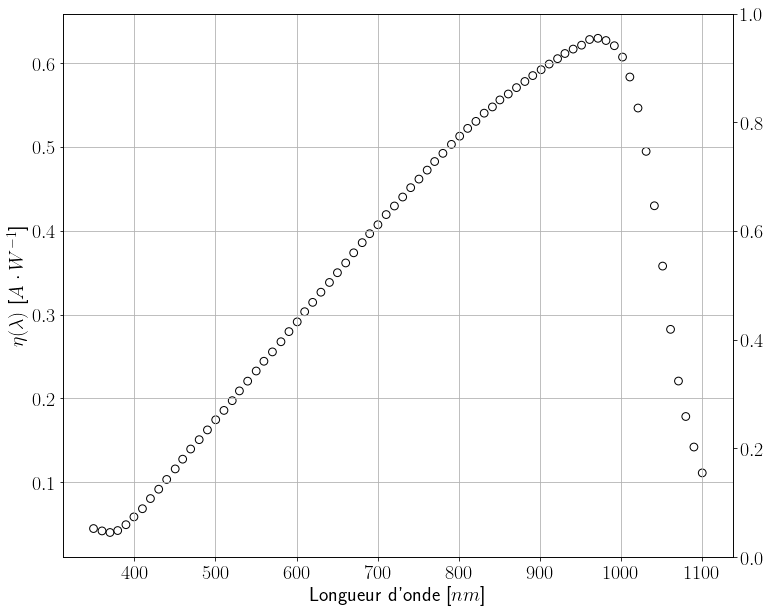

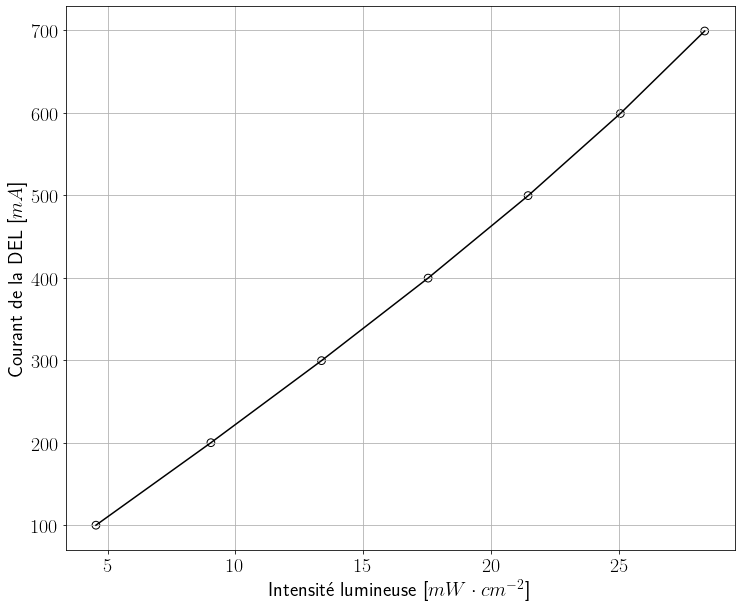

In [139]:
#plt.style.use('./old-style.mplstyle')

fig1 = plt.figure(figsize=(12,10))
ax1 = fig1.subplots(ncols = 1)
ax3 = ax1.twinx()
ax1.scatter(L, eta, edgecolor = 'k', color = 'none', s = 60)#, color = 'red', ls = 'none', marker = 'o')
#ax1.plot(L, fit2(L,*p), color = 'black')

ax1.set_xlabel("Longueur d'onde [$nm$]")
ax1.set_ylabel("$\eta( \lambda)$ [$A \cdot W^{-1}$]")

ax1.grid()

fig2 = plt.figure(figsize=(12,10))
ax2 = fig2.subplots()
ax2.scatter(I, Pinc, edgecolor = 'k', color = 'none', s = 60)
ax2.plot(I, fit(I), color = 'black')
#ax2.plot(I, P(I), color = 'black')

ax2.set_xlabel("Intensité lumineuse [$mW\cdot cm^{-2}$]")
ax2.set_ylabel("Courant de la DEL [$mA$]")

ax2.grid()

#fig1.savefig("Fig01a.pdf", dpi = 300)
#fig2.savefig("Fig01b.pdf", dpi = 300)